# Day 7.1: Introduction to Ensemble Learning

## Table of Contents
1. [Learning Objectives & Prerequisites Review](#learning-objectives--prerequisites-review)
2. [What are Ensemble Methods?](#what-are-ensemble-methods)
3. [The "Wisdom of Crowds" Analogy](#the-wisdom-of-crowds-analogy)
4. [Common Types of Ensemble Methods](#common-types-of-ensemble-methods)
5. [Why Ensembles Work: Bias-Variance Trade-off](#why-ensembles-work-bias-variance-trade-off)
6. [Bagging (Bootstrap Aggregating) Deep Dive](#bagging-bootstrap-aggregating-deep-dive)
7. [Knowledge Check Questions](#knowledge-check-questions)
8. [Summary & Transition](#summary--transition)

## Learning Objectives & Prerequisites Review

**By the end of this session, you will:**
- Understand what ensemble methods are and why they're powerful
- Explain the "wisdom of crowds" principle in machine learning
- Distinguish between bagging, boosting, and stacking approaches
- Understand how bias-variance trade-off relates to ensemble performance
- Describe the bagging process step-by-step

## What are Ensemble Methods?

### Definition
**Ensemble methods** combine the predictions of several base estimators (individual models) to improve generalizability and robustness over a single estimator.

<div style="text-align: center;">
    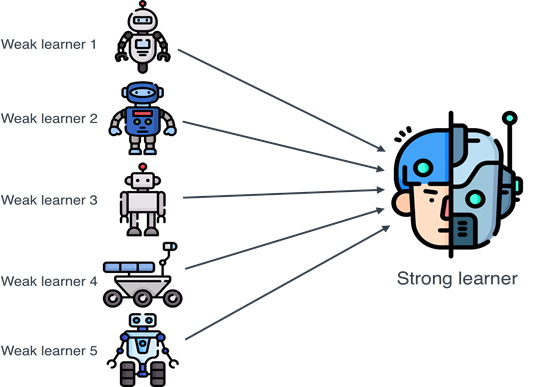
    <br>
    <em>Figure 1: Emsemble learning</em>
</div>

### Core Principle
> *"Multiple models working together can often achieve better performance than any single model on its own."*

### Key Intuition
Think back to Day 6 when we saw how individual decision trees could overfit badly. What if instead of relying on one potentially overfit tree, we could ask many different trees for their opinions and combine their answers?

### Real-World Analogy
Just like you might ask several friends for restaurant recommendations rather than trusting just one person's opinion, ensemble methods consult multiple models before making a final prediction.

### Connection to Previous Learning
Remember from Day 6 how we struggled with decision tree overfitting? Individual trees were either:
- **Too simple** (high bias, underfitting) when we limited depth
- **Too complex** (high variance, overfitting) when we grew deep trees

Ensemble methods offer a clever solution to this dilemma!

## The "Wisdom of Crowds" Analogy

### The Jellybean Jar Experiment
Imagine a jar filled with jellybeans. If you ask 100 people to guess the number:
- Individual guesses vary widely (some too high, some too low)
- The **average** of all guesses is often remarkably close to the true number
- The crowd's wisdom emerges from combining diverse opinions

### Why This Works in Machine Learning

**For the analogy to work, we need:**
1. **Reasonably good individual models** (not random guesses)
2. **Diverse models** that make different types of errors
3. **Independent predictions** (models shouldn't copy each other)

**Example with Decision Trees:**
- Tree 1 might overfit to one subset of data
- Tree 2 might overfit to a different subset
- Tree 3 focuses on different features
- **Combined**: Their errors cancel out, leaving the signal!

### Mathematical Intuition
If each model is correct 60% of the time and their errors are independent:
- 1 model: 60% accuracy
- 3 models (majority vote): ~65% accuracy  
- 10 models: ~75% accuracy
- The improvement compounds!

## Common Types of Ensemble Methods

### 1. Bagging (Bootstrap Aggregating)
**Key Idea:** Train multiple models independently on different random subsets of data

<div style="text-align: center;">
    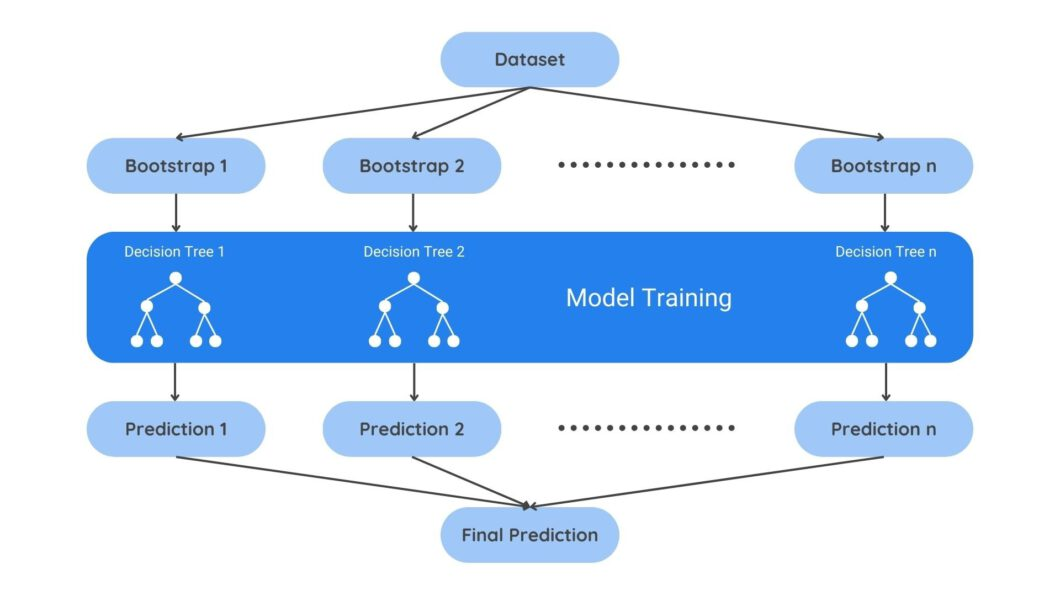
    <br>
    <em>Figure 2: Bagging (Bootstrap Aggregating)</em>
</div>

**Process:**
- Create multiple bootstrap samples from training data
- Train one model on each sample
- Combine predictions (voting/averaging)

**Examples:** Random Forests, Extra Trees

**Strength:** Reduces variance (less overfitting)

### 2. Boosting *(Advanced - Future Topic)*
**Key Idea:** Train models sequentially, each trying to correct previous errors

<div style="text-align: center;">
    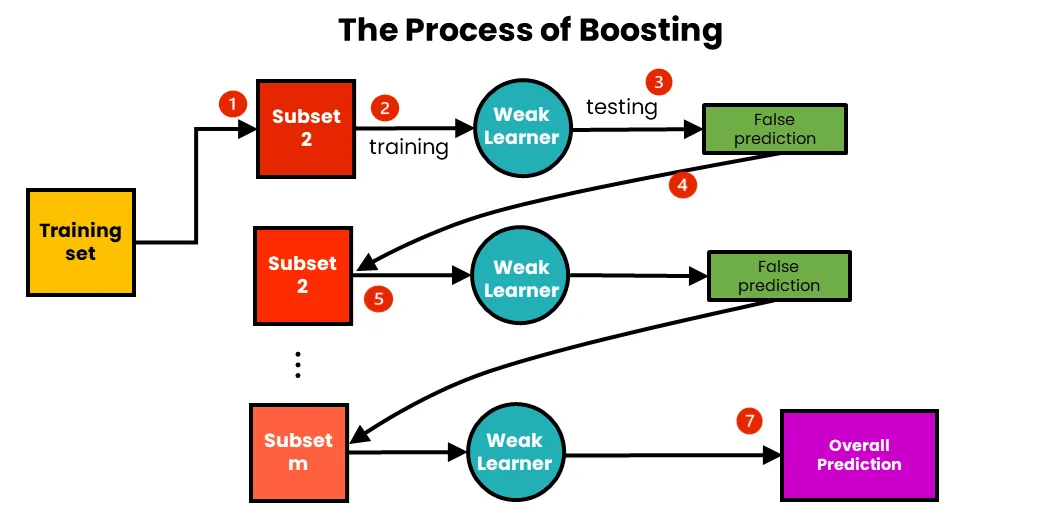
    <br>
    <em>Figure 3: Boosting</em>
</div>

**Process:**
- Train first model
- Identify errors
- Train second model focusing on those errors
- Repeat...

**Examples:** AdaBoost, Gradient Boosting, XGBoost

**Strength:** Reduces bias (better fitting)

### 3. Stacking *(Advanced - Future Topic)*
**Key Idea:** Use a "meta-model" to learn how to best combine other models

<div style="text-align: center;">
    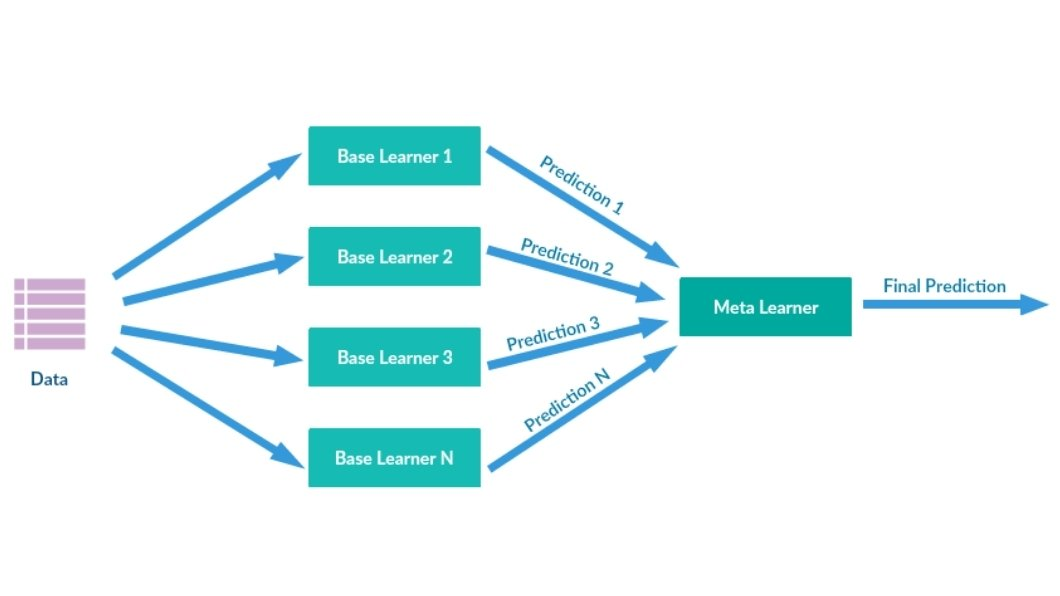
    <br>
    <em>Figure 4: Stacking</em>
</div>

**Process:**
- Train multiple different base models
- Train a meta-model to combine their predictions
- Meta-model learns optimal combination weights

**Strength:** Can capture complex combination patterns

### Which One for Beginners?
We'll focus on **Bagging** and **Random Forests** because they:
- Are easier to understand
- Work well "out of the box"
- Connect directly to decision trees you already know
- Are less prone to overfitting

## Why Ensembles Work: Bias-Variance Trade-off

### Quick Review: Bias vs Variance
From Day 2, remember:
- **Bias:** Error from oversimplified assumptions (underfitting)
- **Variance:** Error from sensitivity to training data (overfitting)

### How Different Ensembles Help

#### Bagging Methods (like Random Forests)
**Primary benefit: Reduce Variance**

* Individual deep tree: Low bias, HIGH variance (overfits)
* Many deep trees averaged: Low bias, LOWER variance (less overfitting)

**Why it works:**
- Each tree overfits to its specific data sample
- Different trees overfit in different ways
- Averaging cancels out the overfitting errors
- Signal remains, noise gets averaged away

#### Connection to Day 6 Decision Trees
Remember how we had to choose between:
- Shallow trees (high bias, low variance)
- Deep trees (low bias, high variance)

Random Forests let us have our cake and eat it too:
- Use deep trees (low bias)
- Average many of them (reduce variance)
- Result: Low bias AND lower variance!

### Practical Implications
- **Single Decision Tree:** Might achieve 85% accuracy but varies wildly with different data
- **Random Forest:** Might achieve 92% accuracy and be much more stable

## Bagging (Bootstrap Aggregating) Deep Dive

### The Complete Process

#### Step 1: Bootstrap Sampling

In [ ]:
Original training set: [A, B, C, D, E] (5 samples)

Bootstrap Sample 1: [A, A, C, D, E] (sampling with replacement)
Bootstrap Sample 2: [B, C, C, D, D] 
Bootstrap Sample 3: [A, B, B, E, E]
...continue for B total samples

**Key insight:** Each bootstrap sample is different but same size as original

#### Step 2: Model Training

In [ ]:
# Pseudocode
for i in range(B):  # B = number of models (e.g., 100)
    bootstrap_sample = bootstrap_resample(original_data)
    model_i = DecisionTree()
    model_i.fit(bootstrap_sample)
    ensemble.add(model_i)

#### Step 3: Prediction Aggregation

**For Classification (Voting):**

In [ ]:
# Each model votes for a class
Model 1 predicts: "Malignant"
Model 2 predicts: "Benign"  
Model 3 predicts: "Malignant"
...
Model 100 predicts: "Malignant"

# Final prediction: Majority vote
# If 65 models say "Malignant", 35 say "Benign"
# Final answer: "Malignant"

**For Regression (Averaging):**

In [ ]:
# Each model predicts a number
Model 1 predicts: 245.3
Model 2 predicts: 251.7
Model 3 predicts: 248.9
...
Model 100 predicts: 249.1

# Final prediction: Average = (245.3 + 251.7 + ... + 249.1) / 100

### Why Bootstrap Sampling?
1. **Creates diversity:** Each model sees slightly different data
2. **Maintains size:** Each bootstrap sample has same size as original
3. **Introduces randomness:** Some samples appear multiple times, others not at all
4. **Theoretical foundation:** Approximates sampling from population

### Visual Learning Exercise
*Suggested drawing: Create a flowchart showing original data → multiple bootstrap samples → multiple trees → combined prediction*

## Knowledge Check Questions

### Section 1: What are Ensemble Methods?
1. **Concept Check:** In your own words, explain why combining multiple models might work better than using just one model.

2. **Connection to Previous Learning:** How do ensemble methods address the overfitting problem we saw with decision trees in Day 6?

3. **Applied Thinking:** If you had to choose between one expert's opinion and the average opinion of 10 reasonably knowledgeable people for an important decision, which would you choose and why?

### Section 2: Wisdom of Crowds
4. **Understanding Check:** What are the three key requirements for the "wisdom of crowds" principle to work in machine learning?

5. **Scenario Analysis:** Suppose you train 5 decision trees on the exact same training data with the same parameters. Would this be a good ensemble? Why or why not?

6. **Mathematical Thinking:** If each model in an ensemble is 70% accurate and their errors are independent, would you expect the ensemble to be more or less than 70% accurate? Explain your reasoning.

### Section 3: Types of Ensemble Methods
7. **Classification:** Match each ensemble type with its main strength:
   - Bagging → ?
   - Boosting → ?
   - Stacking → ?
   
   Options: Reduces bias, Reduces variance, Learns complex combinations

8. **Practical Application:** Given that you're a beginner, why might bagging be a better starting point than boosting or stacking?

### Section 4: Bias-Variance Trade-off
9. **Conceptual Understanding:** Explain how Random Forests solve the dilemma of choosing between shallow trees (high bias) and deep trees (high variance).

10. **Connection Check:** How does the bias-variance trade-off in ensembles relate to the underfitting/overfitting concepts from Day 6?

### Section 5: Bagging Process
11. **Process Understanding:** Walk through the bagging process for a dataset with 1000 samples. If you create 50 bootstrap samples, how many samples will each bootstrap contain?

12. **Prediction Logic:** In a binary classification problem with 100 trees in a bagged ensemble:
    - 60 trees predict "Class A"
    - 40 trees predict "Class B"
    
    What would be the final prediction and why?

13. **Critical Thinking:** Why is sampling "with replacement" important in bootstrap sampling? What would happen if we sampled without replacement?

## Summary & Transition

### What We've Learned
In this session, we've built the foundation for understanding ensemble methods:

1. **Core Concept:** Multiple models working together often outperform individual models
2. **Wisdom of Crowds:** Diverse, reasonably good models can collectively make better decisions
3. **Ensemble Types:** Bagging, boosting, and stacking serve different purposes
4. **Bias-Variance Insight:** Bagging primarily reduces variance, solving overfitting issues
5. **Bagging Process:** Bootstrap sampling → train models → aggregate predictions

### Key Takeaways
- Ensembles address the fundamental challenge from Day 6: the bias-variance trade-off in decision trees
- Bagging allows us to use complex models (deep trees) while reducing overfitting risk
- The success depends on model diversity and reasonable individual performance
- Bootstrap sampling creates the diversity needed for effective ensembles

### Connection to Previous Days
- **Day 6 Decision Trees:** Individual trees are our building blocks
- **Day 4 Evaluation:** We'll need proper metrics to compare ensemble vs individual performance  
- **Day 2 Bias-Variance:** Ensembles provide a practical solution to this fundamental challenge

### Looking Ahead to 7.2: Random Forests
Now that we understand the general principles of ensemble learning and bagging, we're ready to dive deep into **Random Forests** - the most popular and practical implementation of bagging for decision trees. 

In the next session, we'll see how Random Forests add an extra layer of randomness (feature subsampling) to create even more diverse trees, and we'll learn about their practical benefits and limitations.

**Preview Question:** *If bagging already creates diverse trees through bootstrap sampling, why might we want to add even more randomness?*